In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/wiii8/nearest_neighbour.csv')
df1['condition'] = 'wiii8'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/anosmic/nearest_neighbour.csv')
df2['condition'] = 'anosmic'


df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/9047/nearest_neighbour.csv')
df3['condition'] = '9047'

df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/23129/nearest_neighbour.csv')
df4['condition'] = '23129'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/33300/nearest_neighbour.csv')
df5['condition'] = '33300'

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)



condition_order = ['wiii8', 'anosmic', '9047', '23129', '33300']
condition_colors = {
    'wiii8': '#385491',
    'anosmic': '#be0f0a',
    '9047': '#e7533a',
    '23129': '#fc8c59',
    '33300': "#fead61",
}


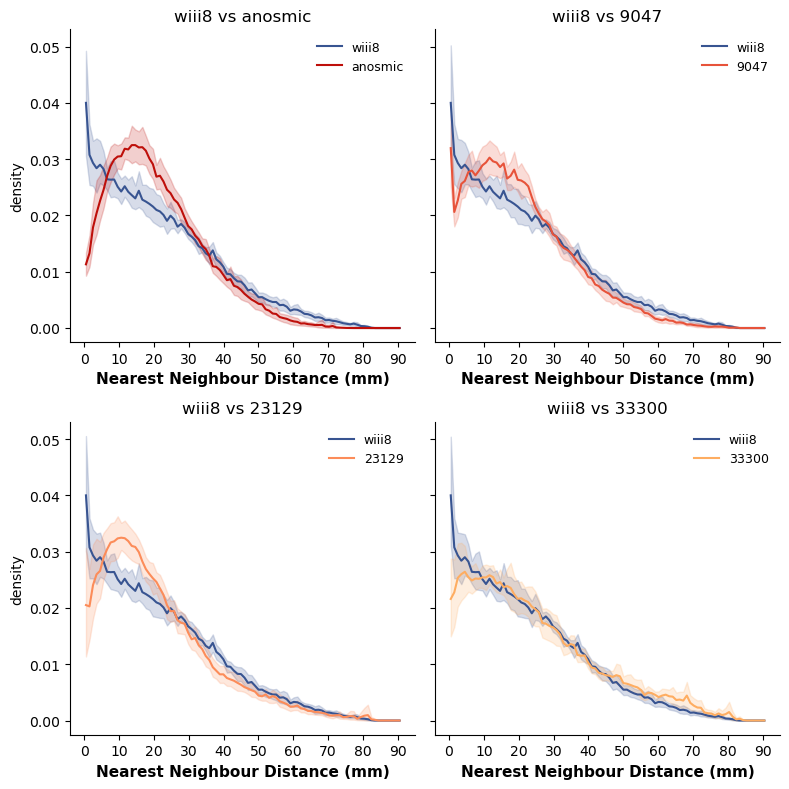

In [51]:

bins = np.linspace(0, 91, 91)  # 0 to 90 in 5 increments
df['bin'] = pd.cut(df['head_distance'], bins, include_lowest=True)
df['bin_center'] = df['bin'].apply(lambda x: x.mid)


# Count per file-condition-bin
# counts = (
#     df.groupby(['filename', 'condition', 'bin_center'])
#     .size()
#     .groupby(['filename', 'condition'], group_keys=False)
#     .apply(lambda x: x / x.sum())
#     .reset_index(name='density')
# )

counts = (
    df.groupby(['filename', 'condition', 'bin_center'])
    .size()
    .unstack(fill_value=0).stack()          # <-- only new line
    .groupby(['filename', 'condition'], group_keys=False)
    .apply(lambda x: x / x.sum())
    .reset_index(name='density')
)


compare_conditions = ['anosmic', '9047', '23129', '33300']
fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharey=True)

for ax, condition in zip(axes.flatten(), compare_conditions):
    plot_data = counts[counts['condition'].isin(['wiii8', condition])]

    sns.lineplot(
        data=plot_data,
        x='bin_center',
        y='density',
        hue='condition',
        hue_order=['wiii8', condition],
        errorbar=('ci', 95),
        palette=condition_colors,
        ax=ax,
    )

    ax.set_title(f'wiii8 vs {condition}')
    ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=11, fontweight='bold')
    ax.set_xticks(np.arange(0, 91, 10))
    ax.legend(frameon=False, title=None, fontsize=9)

# axes[0].set_ylabel('Fraction of Animals', fontsize=11, fontweight='bold')
# for ax in axes[1:]:
#     ax.set_ylabel('')

sns.despine()
plt.tight_layout()

plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/sensory-mutants/nearest_neighbour.pdf', format='pdf')
plt.show()



,control,condition,n_control,n_condition,U,p_value
0,wiii8,anosmic,10,10,67.0,0.212294
1,wiii8,9047,10,10,72.0,0.104110
2,wiii8,23129,10,10,60.0,0.472676
3,wiii8,33300,10,10,22.0,0.037635


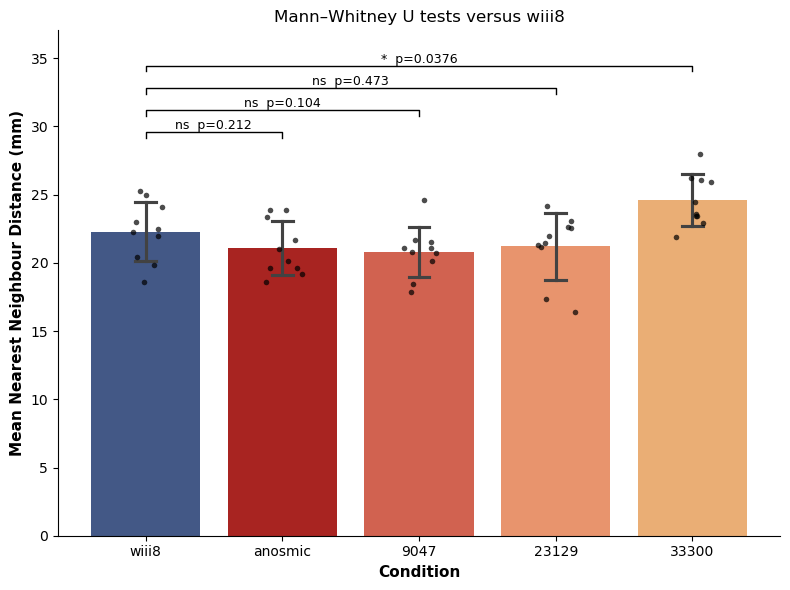

In [ ]:
from scipy.stats import mannwhitneyu

mean_head_distance = (
    df.groupby(['filename', 'condition'])['head_distance']
      .mean()
      .reset_index(name='mean_head_distance')
      .dropna(subset=['mean_head_distance'])
)

control = 'wiii8'
compare_conditions = [condition for condition in condition_order if condition != control]
plot_data = mean_head_distance[mean_head_distance['condition'].isin(condition_order)].copy()

# Compare each mutant with the wiii8 control using independent file means.
control_values = plot_data.loc[
    plot_data['condition'].eq(control), 'mean_head_distance'
].to_numpy()

test_results = []
for condition in compare_conditions:
    mutant_values = plot_data.loc[
        plot_data['condition'].eq(condition), 'mean_head_distance'
    ].to_numpy()
    u_stat, p_value = mannwhitneyu(
        control_values, mutant_values, alternative='two-sided', method='auto'
    )
    test_results.append({
        'control': control,
        'condition': condition,
        'n_control': len(control_values),
        'n_condition': len(mutant_values),
        'U': u_stat,
        'p_value': p_value,
    })

mann_whitney_results = pd.DataFrame(test_results)
display(mann_whitney_results)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    data=plot_data,
    x='condition',
    y='mean_head_distance',
    hue='condition',
    order=condition_order,
    hue_order=condition_order,
    errorbar='sd',
    capsize=0.15,
    palette=condition_colors,
    dodge=False,
    legend=False,
    ax=ax,
)
sns.stripplot(
    data=plot_data,
    x='condition',
    y='mean_head_distance',
    order=condition_order,
    color='black',
    size=4,
    jitter=0.15,
    alpha=0.7,
    ax=ax,
)

def significance_label(p_value):
    if p_value < 0.0001:
        return '****'
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'

# Add one bracket for every wiii8-versus-mutant comparison.
data_min = plot_data['mean_head_distance'].min()
data_max = plot_data['mean_head_distance'].max()
data_range = data_max - data_min
if data_range == 0:
    data_range = max(abs(data_max), 1)

bracket_height = 0.035 * data_range
for comparison_number, result in enumerate(test_results, start=1):
    x_control = condition_order.index(control)
    x_mutant = condition_order.index(result['condition'])
    y = data_max + (0.10 + 0.14 * (comparison_number - 1)) * data_range
    ax.plot(
        [x_control, x_control, x_mutant, x_mutant],
        [y, y + bracket_height, y + bracket_height, y],
        color='black',
        linewidth=1,
    )
    ax.text(
        (x_control + x_mutant) / 2,
        y + bracket_height,
        f"{significance_label(result['p_value'])}  p={result['p_value']:.3g}",
        ha='center',
        va='bottom',
        fontsize=9,
    )

ax.set_ylim(top=data_max + 0.78 * data_range)
ax.set_xlabel('Condition', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Nearest Neighbour Distance (mm)', fontsize=11, fontweight='bold')
ax.set_title('Mann–Whitney U tests versus wiii8')
sns.despine()
plt.tight_layout()
plt.show()


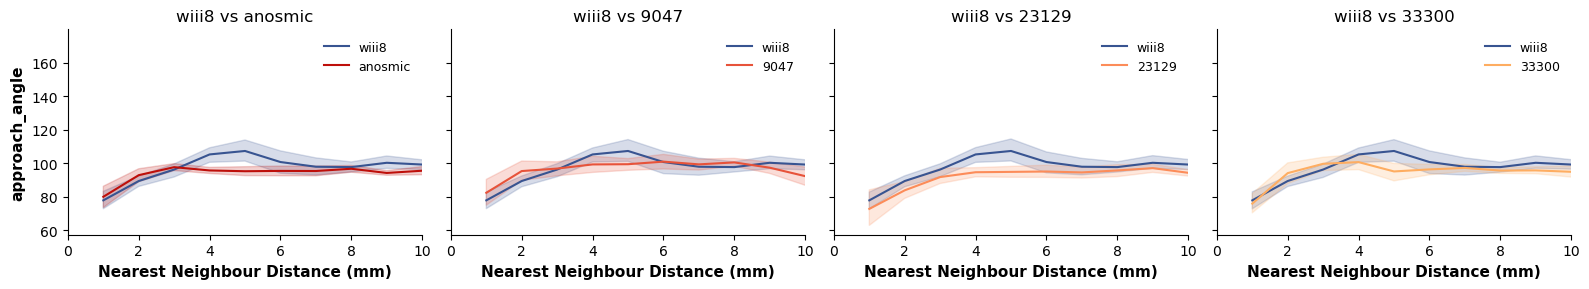

In [ ]:
df_speed = df.copy()

bins = list(range(0, 90, 1))
df_speed['bin'] = pd.cut(df_speed['head_distance'], bins, include_lowest=True)
df_speed['bin_right'] = df_speed['bin'].apply(lambda x: x.right).astype(float)


speed_plot = (
    df_speed.groupby(['condition', 'filename', 'bin_right'], as_index=False)['approach_angle']
      .mean()
)


compare_conditions = ['anosmic', '9047', '23129', '33300']
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)

for ax, condition in zip(axes, compare_conditions):
    plot_data = speed_plot[speed_plot['condition'].isin(['wiii8', condition])]

    sns.lineplot(
        data=plot_data,
        x='bin_right',
        y='approach_angle',
        hue='condition',
        hue_order=['wiii8', condition],
        errorbar=('ci', 95),
        palette=condition_colors,
        ax=ax,
    )

    ax.set_title(f'wiii8 vs {condition}')
    ax.set_xlim(0, 10)
    # ax.set_ylim(0.3, 1.1)
    ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, title=None, fontsize=9)

axes[0].set_ylabel('approach_angle', fontsize=11, fontweight='bold')
for ax in axes[1:]:
    ax.set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

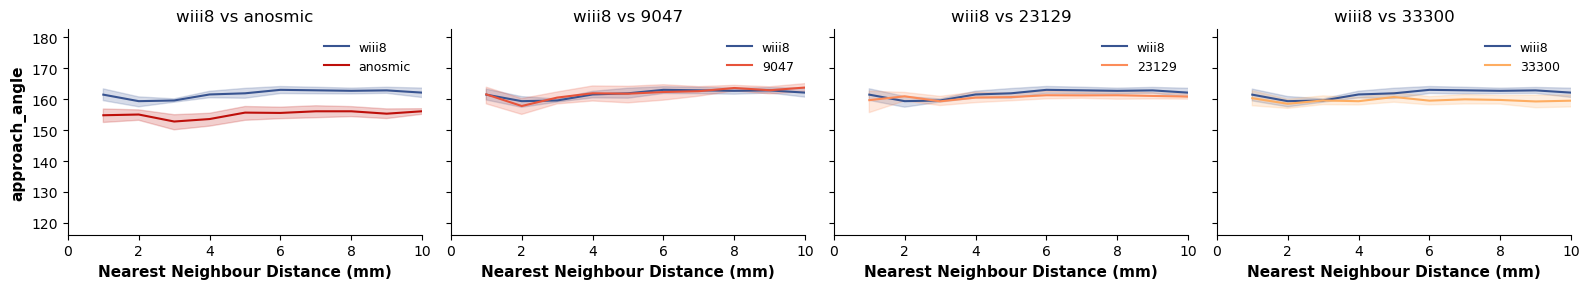

In [ ]:
df_speed = df.copy()

bins = list(range(0, 90, 1))
df_speed['bin'] = pd.cut(df_speed['head_distance'], bins, include_lowest=True)
df_speed['bin_right'] = df_speed['bin'].apply(lambda x: x.right).astype(float)


speed_plot = (
    df_speed.groupby(['condition', 'filename', 'bin_right'], as_index=False)['angle']
      .mean()
)


compare_conditions = ['anosmic', '9047', '23129', '33300']
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)

for ax, condition in zip(axes, compare_conditions):
    plot_data = speed_plot[speed_plot['condition'].isin(['wiii8', condition])]

    sns.lineplot(
        data=plot_data,
        x='bin_right',
        y='angle',
        hue='condition',
        hue_order=['wiii8', condition],
        errorbar=('ci', 95),
        palette=condition_colors,
        ax=ax,
    )

    ax.set_title(f'wiii8 vs {condition}')
    ax.set_xlim(0, 10)
    # ax.set_ylim(0.3, 1.1)
    ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, title=None, fontsize=9)

axes[0].set_ylabel('approach_angle', fontsize=11, fontweight='bold')
for ax in axes[1:]:
    ax.set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

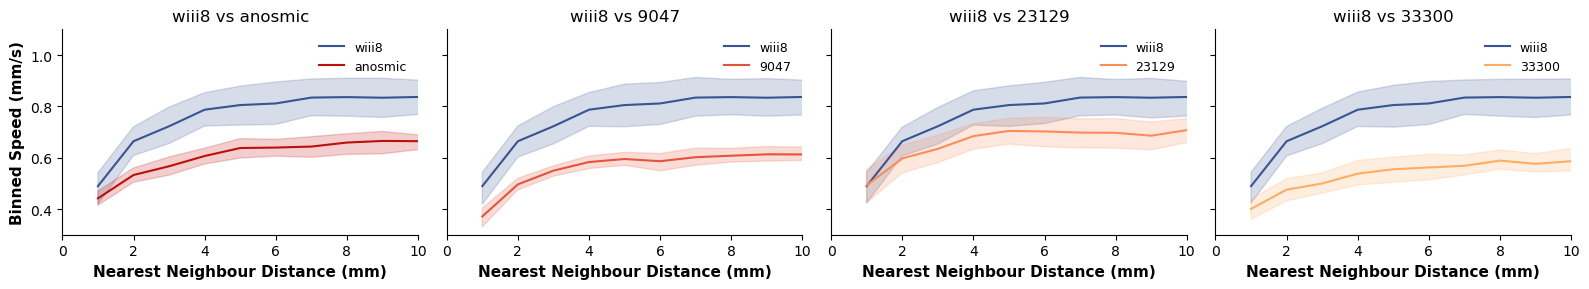

In [ ]:
df_speed = df.copy()

bins = list(range(0, 90, 1))
df_speed['bin'] = pd.cut(df_speed['head_distance'], bins, include_lowest=True)
df_speed['bin_right'] = df_speed['bin'].apply(lambda x: x.right).astype(float)


speed_plot = (
    df_speed.groupby(['condition', 'filename', 'bin_right'], as_index=False)['speed']
      .mean()
)


compare_conditions = ['anosmic', '9047', '23129', '33300']
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)

for ax, condition in zip(axes, compare_conditions):
    plot_data = speed_plot[speed_plot['condition'].isin(['wiii8', condition])]

    sns.lineplot(
        data=plot_data,
        x='bin_right',
        y='speed',
        hue='condition',
        hue_order=['wiii8', condition],
        errorbar=('ci', 95),
        palette=condition_colors,
        ax=ax,
    )

    ax.set_title(f'wiii8 vs {condition}')
    ax.set_xlim(0, 10)
    ax.set_ylim(0.3, 1.1)
    ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, title=None, fontsize=9)

axes[0].set_ylabel('Binned Speed (mm/s)', fontsize=11, fontweight='bold')
for ax in axes[1:]:
    ax.set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

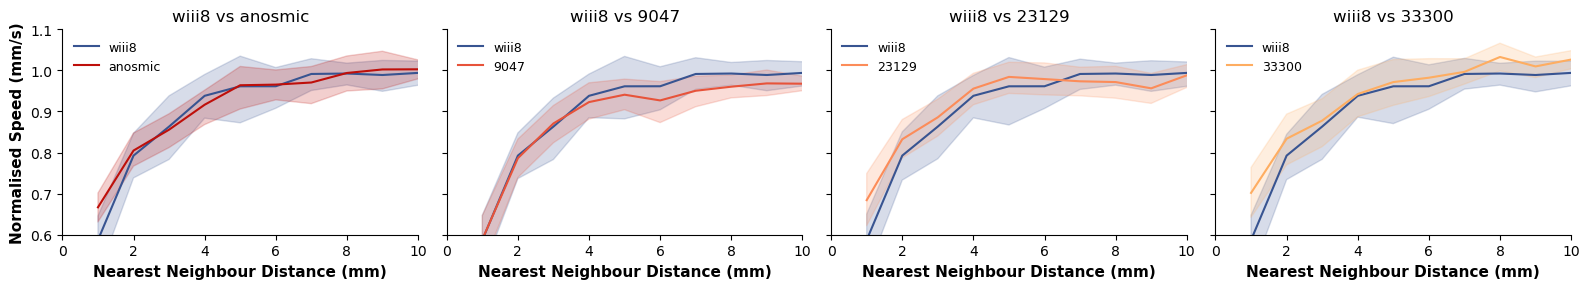

In [ ]:

df_norm = df.copy()

bins = list(range(0, 90, 1))  # [0, 10, 20, ..., 100]
df_norm['bin'] = pd.cut(df_norm['head_distance'], bins, include_lowest=True) #body-body ; closest_node_distance ; head_distance
df_norm['bin_right'] = df_norm['bin'].apply(lambda x: x.right).astype(float)


baseline = (
    df_norm[(df_norm['bin_right'] >= 10) & (df_norm['bin_right'] < 20)]
      .groupby(['condition', 'filename'], as_index=False)['speed']
      .mean()
      .rename(columns={'speed': 'mean_speed_10_20'})
)

df_norm = df_norm.merge(baseline, on=['condition', 'filename'], how='left')
df_norm = df_norm.dropna(subset=['mean_speed_10_20']).copy()
df_norm['speed_norm'] = df_norm['speed'] / df_norm['mean_speed_10_20']


df_plot = (
    df_norm.groupby(['condition', 'filename', 'bin_right'], as_index=False)['speed_norm']
      .mean()
)


compare_conditions = ['anosmic', '9047', '23129', '33300']
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)

for ax, condition in zip(axes, compare_conditions):
    plot_data = df_plot[df_plot['condition'].isin(['wiii8', condition])]

    sns.lineplot(
        data=plot_data,
        x='bin_right',
        y='speed_norm',
        hue='condition',
        hue_order=['wiii8', condition],
        errorbar=('ci', 95),
        palette=condition_colors,
        ax=ax,
    )

    ax.set_title(f'wiii8 vs {condition}')
    ax.set_ylim(0.6, 1.1)
    ax.set_xlim(0, 10)
    ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, title=None, fontsize=9)

axes[0].set_ylabel('Normalised Speed (mm/s)', fontsize=11, fontweight='bold')
for ax in axes[1:]:
    ax.set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

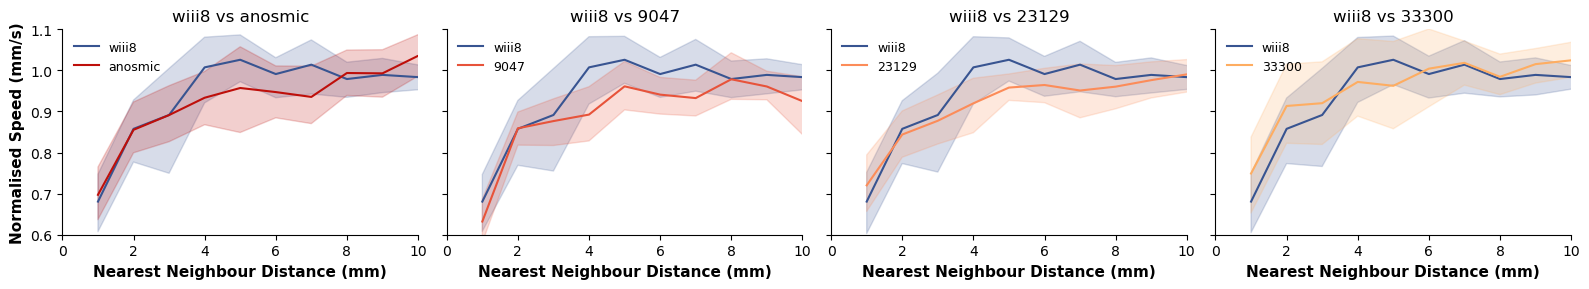

In [ ]:

df_norm = df.copy()

df_norm = df_norm[df_norm['approach_angle'] < 35].copy()

bins = list(range(0, 90, 1))  # [0, 10, 20, ..., 100]
df_norm['bin'] = pd.cut(df_norm['head_distance'], bins, include_lowest=True) #body-body ; closest_node_distance ; head_distance
df_norm['bin_right'] = df_norm['bin'].apply(lambda x: x.right).astype(float)


baseline = (
    df_norm[(df_norm['bin_right'] >= 10) & (df_norm['bin_right'] < 20)]
      .groupby(['condition', 'filename'], as_index=False)['speed']
      .mean()
      .rename(columns={'speed': 'mean_speed_10_20'})
)

df_norm = df_norm.merge(baseline, on=['condition', 'filename'], how='left')
df_norm = df_norm.dropna(subset=['mean_speed_10_20']).copy()
df_norm['speed_norm'] = df_norm['speed'] / df_norm['mean_speed_10_20']


df_plot = (
    df_norm.groupby(['condition', 'filename', 'bin_right'], as_index=False)['speed_norm']
      .mean()
)


compare_conditions = ['anosmic', '9047', '23129', '33300']
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)

for ax, condition in zip(axes, compare_conditions):
    plot_data = df_plot[df_plot['condition'].isin(['wiii8', condition])]

    sns.lineplot(
        data=plot_data,
        x='bin_right',
        y='speed_norm',
        hue='condition',
        hue_order=['wiii8', condition],
        errorbar=('ci', 95),
        palette=condition_colors,
        ax=ax,
    )

    ax.set_title(f'wiii8 vs {condition}')
    ax.set_ylim(0.6, 1.1)
    ax.set_xlim(0, 10)
    ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, title=None, fontsize=9)

axes[0].set_ylabel('Normalised Speed (mm/s)', fontsize=11, fontweight='bold')
for ax in axes[1:]:
    ax.set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()